# Smart Outcome Predictor
Predicting course completion (classification) and final score (regression) using ensemble learning - Bagging, Boosting, Voting and Stacking.

## Import Libraries

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (BaggingClassifier, BaggingRegressor,
                               AdaBoostClassifier, AdaBoostRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor,
                               VotingClassifier, StackingClassifier, StackingRegressor)

from lightgbm import LGBMClassifier, LGBMRegressor

from xgboost import XGBClassifier, XGBRegressor

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, mean_absolute_error, mean_squared_error, r2_score)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Load Dataset

In [65]:
df = pd.read_csv("../Dataset/Smart_Outcome_Predictor.csv")
df.head()

,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


## EDA - Overview

In [66]:
df.info()
df.isnull().sum().sort_values(ascending=False)
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             5200 non-null   int64  
 1   age                    5200 non-null   int64  
 2   country_region         5200 non-null   object 
 3   device_type            5200 non-null   object 
 4   education_background   5200 non-null   object 
 5   course_level           5200 non-null   object 
 6   course_category        5200 non-null   object 
 7   course_start_date      5200 non-null   object 
 8   week_of_year           5200 non-null   int64  
 9   sessions               5200 non-null   int64  
 10  time_spent_hours       5088 non-null   float64
 11  videos_watched         5200 non-null   int64  
 12  quiz_attempts          5200 non-null   int64  
 13  assignments_submitted  5200 non-null   int64  
 14  forum_posts            5200 non-null   int64  
 15  avg_

time_spent_hours         112
avg_quiz_score            81
attendance_rate           80
student_id                 0
completion_status          0
forum_posts                0
assignments_submitted      0
quiz_attempts              0
videos_watched             0
sessions                   0
age                        0
week_of_year               0
course_start_date          0
course_category            0
course_level               0
education_background       0
device_type                0
country_region             0
final_score                0
dtype: int64

## EDA - Target Distributions

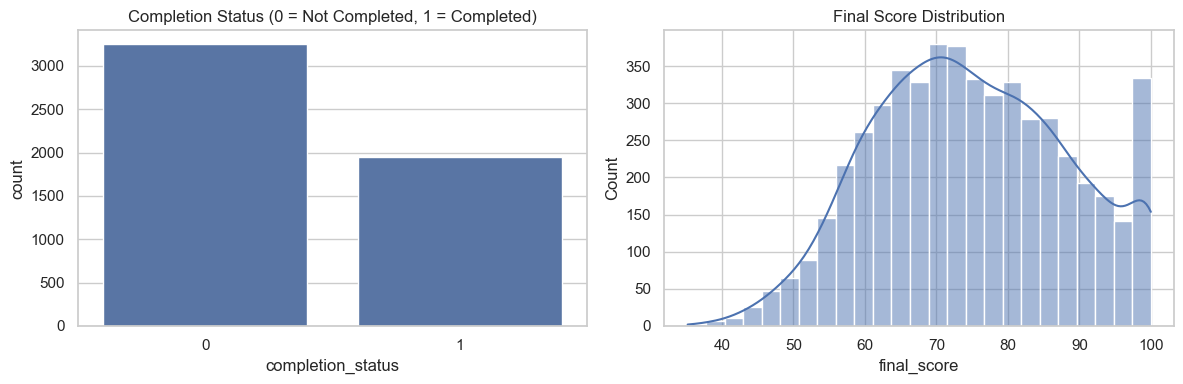

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(x='completion_status', data=df, ax=axes[0])
axes[0].set_title("Completion Status (0 = Not Completed, 1 = Completed)")
sns.histplot(df['final_score'], bins=25, kde=True, ax=axes[1])
axes[1].set_title("Final Score Distribution")
plt.tight_layout()
plt.show()

## Handling Missing Values

In [68]:
for col in ['time_spent_hours', 'avg_quiz_score', 'attendance_rate']:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum().sum()

0

## Handling the Course Start Date Column

In [69]:
df['course_start_date'] = pd.to_datetime(df['course_start_date'])
df['start_month'] = df['course_start_date'].dt.month
df['start_weekday'] = df['course_start_date'].dt.dayofweek
df = df.drop(columns=['course_start_date'])

## Encoding Categorical Columns

In [70]:
categorical_cols = ['country_region', 'device_type', 'education_background', 'course_level', 'course_category']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded = df_encoded.drop(columns=['student_id'])
df_encoded.head()

,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,...,education_background_HighSchool,education_background_Undergrad,education_background_WorkingPro,course_level_Advancedspoi,course_level_Beginner,course_level_Intermediate,course_category_Data,course_category_Design,course_category_Marketing,course_category_Programming
0,32,12,1,7.6,1,6,1,1,53.3,0.655,...,False,True,False,False,False,True,False,False,False,False
1,17,34,16,27.2,6,4,7,1,51.5,1.000,...,False,True,False,False,False,True,False,False,False,True
2,25,39,6,7.1,16,2,2,0,62.2,0.810,...,False,False,False,False,False,False,False,False,False,True
3,26,10,34,22.1,57,9,6,0,59.3,0.875,...,False,True,False,False,True,False,False,True,False,False
4,26,12,22,32.3,41,9,2,0,65.1,0.814,...,False,False,True,False,False,False,False,False,False,False


## Checking relationship between the data

<Axes: >

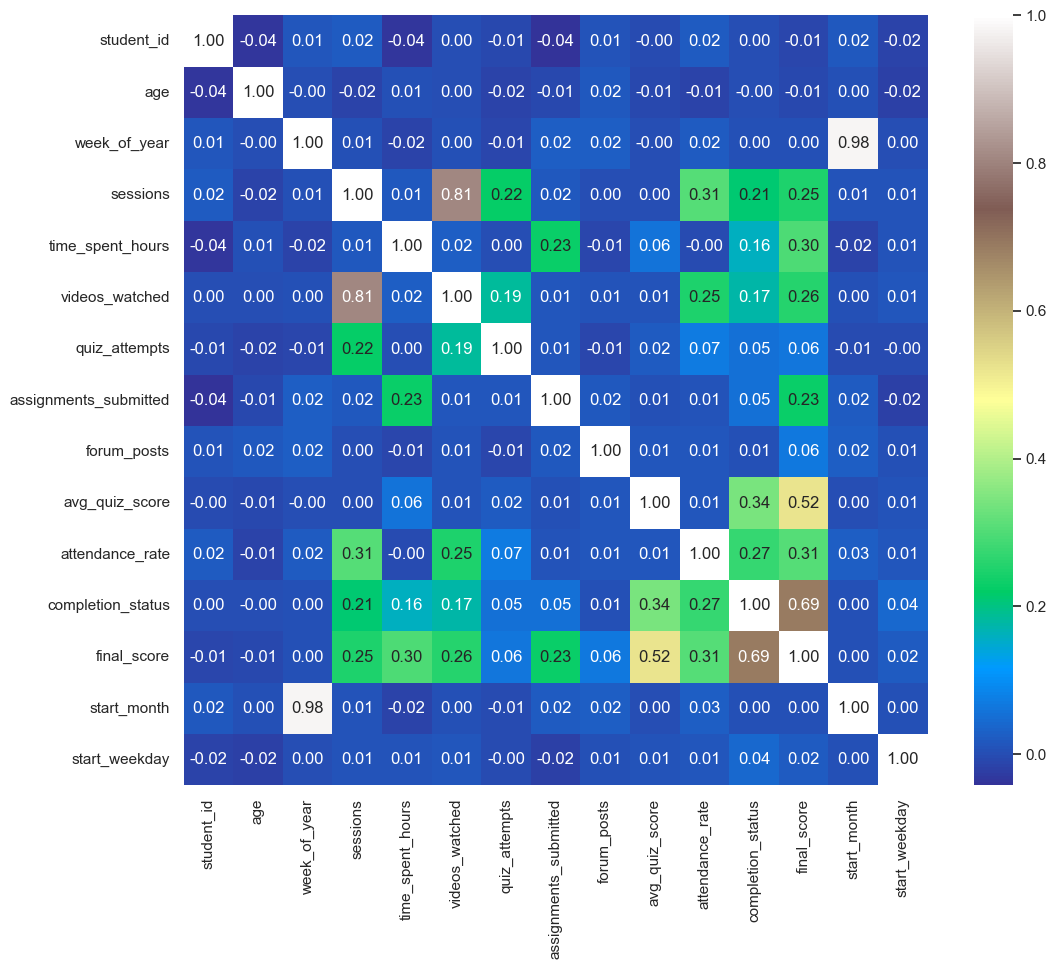

In [71]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="terrain", cbar=True)

## Dropping the unnecessary columns

In [72]:
df.drop(columns=['student_id','age','start_weekday'], inplace=True)
df.head()

,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score,start_month
0,Europe,Laptop,Undergrad,Intermediate,Business,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8,3
1,Europe,Laptop,Undergrad,Intermediate,Programming,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0,8
2,Europe,Mobile,Graduate,Advanced,Programming,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5,9
3,Asia,Mobile,Undergrad,Beginner,Design,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5,3
4,Asia,Tablet,WorkingPro,Advanced,Business,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4,3


# Part B: Dataset Understanding & Preparation

## Task 6: Identify Features and Target Variables

In [73]:
features = df_encoded.drop(columns=['completion_status', 'final_score'])
target_cls = df_encoded['completion_status']
target_reg = df_encoded['final_score']

print("Feature count:", features.shape[1])

Feature count: 28


## Task 7: Train-Test Split for Both Tasks

In [74]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    features, target_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=target_cls
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    features, target_reg, test_size=0.2, random_state=RANDOM_STATE
)

## Task 8: Preprocessing Pipeline (Scaling)

In [75]:
def make_pipeline(model):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

## Evaluation Helper Functions

In [76]:
cls_results = []
reg_results = []

def add_cls_result(name, model, X_test, y_test):
    pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if hasattr(model, "predict_proba") else np.nan
    cls_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred),
        'ROC-AUC': auc
    })

def add_reg_result(name, model, X_test, y_test):
    pred = model.predict(X_test)
    reg_results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2 Score': r2_score(y_test, pred)
    })

def train_classifier(name, model, X_train, y_train, X_test, y_test):
    pipeline = make_pipeline(model)
    pipeline.fit(X_train, y_train)
    add_cls_result(name, pipeline, X_test, y_test)
    return pipeline

def train_regressor(name, model, X_train, y_train, X_test, y_test):
    pipeline = make_pipeline(model)
    pipeline.fit(X_train, y_train)
    add_reg_result(name, pipeline, X_test, y_test)
    return pipeline

def time_training(model, X_train, y_train):
    start = time.time()
    make_pipeline(model).fit(X_train, y_train)
    return time.time() - start

# Part C: Bagging (Bootstrap Aggregating)

## Task 9: Bagging Classifier

In [77]:
bagging_clf = train_classifier(
    "Bagging Classifier",
    BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE), n_estimators=100, random_state=RANDOM_STATE),
    Xc_train, yc_train, Xc_test, yc_test
)
bagging_clf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0


## Task 10: Bagging Regressor

In [78]:
bagging_reg = train_regressor(
    "Bagging Regressor",
    BaggingRegressor(estimator=DecisionTreeRegressor(random_state=RANDOM_STATE), n_estimators=100, random_state=RANDOM_STATE),
    Xr_train, yr_train, Xr_test, yr_test
)

## Task 11: Bagging vs Single Base Model

In [79]:
single_tree_clf = train_classifier("Single Decision Tree", DecisionTreeClassifier(random_state=RANDOM_STATE),
                                    Xc_train, yc_train, Xc_test, yc_test)

single_tree_reg = train_regressor("Single Decision Tree", DecisionTreeRegressor(random_state=RANDOM_STATE),
                                   Xr_train, yr_train, Xr_test, yr_test)

pd.DataFrame(cls_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Bagging Classifier,0.705769,0.617978,0.564103,0.589812,0.762091
1,Single Decision Tree,0.620192,0.494382,0.564103,0.526946,0.608974


# Part D: Boosting Algorithms

## Task 12-13: AdaBoost Classifier and Regressor

In [80]:
adaboost_clf = train_classifier("AdaBoost Classifier", AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
                                 Xc_train, yc_train, Xc_test, yc_test)

adaboost_reg = train_regressor("AdaBoost Regressor", AdaBoostRegressor(n_estimators=100, random_state=RANDOM_STATE),
                                Xr_train, yr_train, Xr_test, yr_test)

## Task 14: How Weak Learners Improve Sequentially

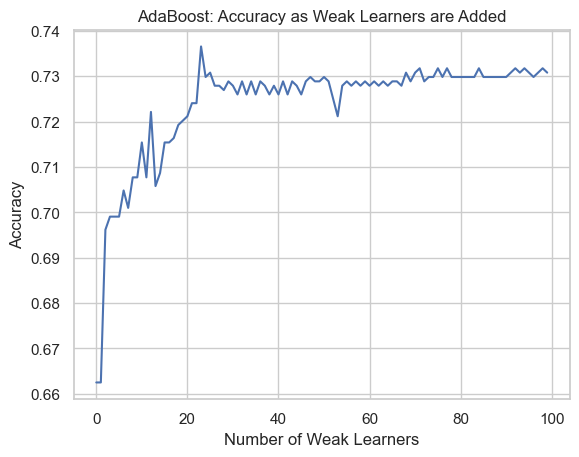

In [81]:
scaled_test = adaboost_clf.named_steps['scaler'].transform(Xc_test)
staged_accuracy = [accuracy_score(yc_test, pred) for pred in adaboost_clf.named_steps['model'].staged_predict(scaled_test)]

plt.plot(staged_accuracy)
plt.xlabel("Number of Weak Learners")
plt.ylabel("Accuracy")
plt.title("AdaBoost: Accuracy as Weak Learners are Added")
plt.show()

## Task 15-16: Gradient Boosting Classifier and Regressor

In [82]:
gb_clf = train_classifier("Gradient Boosting Classifier", GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=RANDOM_STATE),
                           Xc_train, yc_train, Xc_test, yc_test)

gb_reg = train_regressor("Gradient Boosting Regressor", GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, random_state=RANDOM_STATE),
                          Xr_train, yr_train, Xr_test, yr_test)

## Task 17: Effect of Learning Rate and Number of Estimators

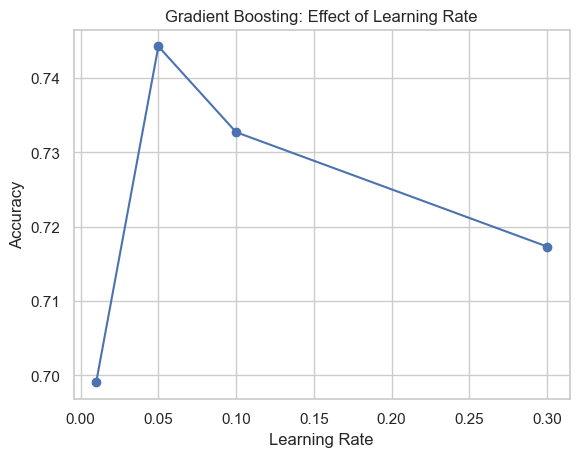

In [83]:
learning_rates = [0.01, 0.05, 0.1, 0.3]
lr_scores = []

for lr in learning_rates:
    model = make_pipeline(GradientBoostingClassifier(n_estimators=100, learning_rate=lr, random_state=RANDOM_STATE))
    model.fit(Xc_train, yc_train)
    lr_scores.append(accuracy_score(yc_test, model.predict(Xc_test)))

plt.plot(learning_rates, lr_scores, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting: Effect of Learning Rate")
plt.show()

## Task 18-19: LightGBM Classifier and Regressor

In [84]:
lgbm_clf = train_classifier("LightGBM Classifier", LGBMClassifier(n_estimators=150, random_state=RANDOM_STATE, verbose=-1),
                             Xc_train, yc_train, Xc_test, yc_test)

lgbm_reg = train_regressor("LightGBM Regressor", LGBMRegressor(n_estimators=150, random_state=RANDOM_STATE, verbose=-1),
                            Xr_train, yr_train, Xr_test, yr_test)

## Task 20: Performance and Training Efficiency

In [85]:
gb_time = time_training(GradientBoostingClassifier(n_estimators=150, random_state=RANDOM_STATE), Xc_train, yc_train)
lgbm_time = time_training(LGBMClassifier(n_estimators=150, random_state=RANDOM_STATE, verbose=-1), Xc_train, yc_train)

print("Gradient Boosting training time:", round(gb_time, 3), "seconds")
print("LightGBM training time:", round(lgbm_time, 3), "seconds")

Gradient Boosting training time: 1.684 seconds
LightGBM training time: 0.132 seconds


## Task 21-22: XGBoost Classifier and Regressor

In [86]:
xgb_clf = train_classifier("XGBoost Classifier", XGBClassifier(n_estimators=150, random_state=RANDOM_STATE, eval_metric='logloss'),
                            Xc_train, yc_train, Xc_test, yc_test)

xgb_reg = train_regressor("XGBoost Regressor", XGBRegressor(n_estimators=150, random_state=RANDOM_STATE),
                           Xr_train, yr_train, Xr_test, yr_test)

## Task 23: Comparing Boosting Models

In [87]:
boosting_names = ['AdaBoost Classifier', 'Gradient Boosting Classifier', 'LightGBM Classifier', 'XGBoost Classifier']
pd.DataFrame(cls_results)[pd.DataFrame(cls_results)['Model'].isin(boosting_names)]

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,AdaBoost Classifier,0.730769,0.669753,0.556410,0.607843,0.785897
3,Gradient Boosting Classifier,0.729808,0.656160,0.587179,0.619756,0.785807
4,LightGBM Classifier,0.716346,0.636103,0.569231,0.600812,0.771097
5,XGBoost Classifier,0.710577,0.621918,0.582051,0.601325,0.752280


# Part E: Voting & Stacking Ensembles

## Task 24: Voting Classifier

In [88]:
base_estimators = [
    ('logreg', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ('tree', DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier())
]

voting_hard = train_classifier("Voting Classifier (Hard)", VotingClassifier(estimators=base_estimators, voting='hard'),
                                Xc_train, yc_train, Xc_test, yc_test)

## Task 25: Hard Voting vs Soft Voting

In [89]:
voting_soft = train_classifier("Voting Classifier (Soft)", VotingClassifier(estimators=base_estimators, voting='soft'),
                                Xc_train, yc_train, Xc_test, yc_test)

print("Hard Voting Accuracy:", accuracy_score(yc_test, voting_hard.predict(Xc_test)))
print("Soft Voting Accuracy:", accuracy_score(yc_test, voting_soft.predict(Xc_test)))

Hard Voting Accuracy: 0.7230769230769231
Soft Voting Accuracy: 0.6711538461538461


## Task 26: Stacking Classifier with a Meta-Learner

In [90]:
stacking_clf = train_classifier(
    "Stacking Classifier",
    StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), cv=5),
    Xc_train, yc_train, Xc_test, yc_test
)

## Task 27: Stacking Regressor

In [91]:
base_regressors = [
    ('tree', DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ('linreg', LinearRegression())
]

stacking_reg = train_regressor(
    "Stacking Regressor",
    StackingRegressor(estimators=base_regressors, final_estimator=LinearRegression(), cv=5),
    Xr_train, yr_train, Xr_test, yr_test
)

# Part F: Model Evaluation & Comparison

## Task 28: Classification Model Evaluation

In [92]:
cls_results_df = pd.DataFrame(cls_results)
cls_results_df.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
8,Stacking Classifier,0.740385,0.680723,0.579487,0.626039,0.793396
3,Gradient Boosting Classifier,0.729808,0.656160,0.587179,0.619756,0.785807
2,AdaBoost Classifier,0.730769,0.669753,0.556410,0.607843,0.785897
5,XGBoost Classifier,0.710577,0.621918,0.582051,0.601325,0.752280
4,LightGBM Classifier,0.716346,0.636103,0.569231,0.600812,0.771097
6,Voting Classifier (Hard),0.723077,0.658385,0.543590,0.595506,NaN
0,Bagging Classifier,0.705769,0.617978,0.564103,0.589812,0.762091
7,Voting Classifier (Soft),0.671154,0.561856,0.558974,0.560411,0.735467
1,Single Decision Tree,0.620192,0.494382,0.564103,0.526946,0.608974


## Task 29: Regression Model Evaluation

In [93]:
reg_results_df = pd.DataFrame(reg_results)
reg_results_df.sort_values("R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
6,Stacking Regressor,7.828865,9.736455,0.492621
3,Gradient Boosting Regressor,7.907924,9.829606,0.482866
4,LightGBM Regressor,8.009774,9.948806,0.470247
0,Bagging Regressor,8.028098,10.008125,0.463911
2,AdaBoost Regressor,8.616152,10.572022,0.401799
5,XGBoost Regressor,8.510792,10.586776,0.400128
1,Single Decision Tree,11.373654,14.186086,-0.077101


## Task 30: Comparing All Ensemble Techniques

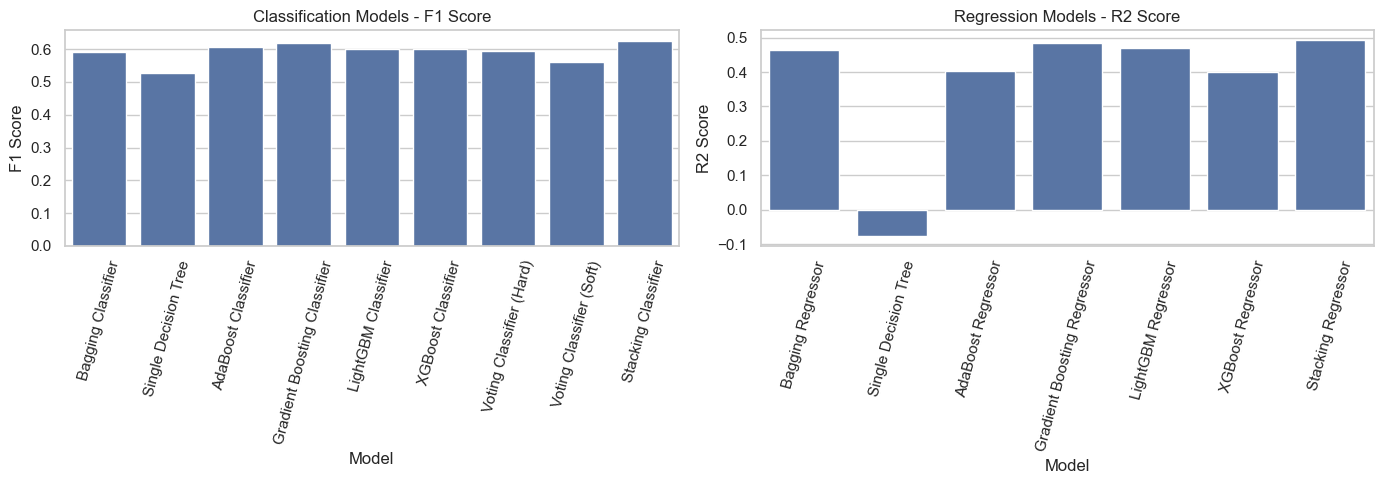

Best Classification Model: Stacking Classifier | F1 Score: 0.6260387811634349
Best Regression Model: Stacking Regressor | R2 Score: 0.49262055138068095


In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(data=cls_results_df, x="Model", y="F1 Score", ax=axes[0])
axes[0].set_title("Classification Models - F1 Score")
axes[0].tick_params(axis='x', rotation=75)

sns.barplot(data=reg_results_df, x="Model", y="R2 Score", ax=axes[1])
axes[1].set_title("Regression Models - R2 Score")
axes[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

best_cls = cls_results_df.loc[cls_results_df['F1 Score'].idxmax()]
best_reg = reg_results_df.loc[reg_results_df['R2 Score'].idxmax()]

print("Best Classification Model:", best_cls['Model'], "| F1 Score:", best_cls['F1 Score'])
print("Best Regression Model:", best_reg['Model'], "| R2 Score:", best_reg['R2 Score'])

# Part G: Final Analysis & Reporting

## Task 31: Final Report

**Impact of Bagging vs Boosting**
Bagging (like the Bagging Classifier/Regressor) mainly reduces variance by training many models in parallel on different data samples and averaging them out, making it more stable against overfitting. Boosting (AdaBoost, Gradient Boosting, LightGBM, XGBoost) reduces bias by training models sequentially, where each new model corrects the mistakes of the previous ones, usually resulting in higher accuracy but with more risk of overfitting if not tuned carefully.

**Comparison of Tree-Based Boosting Algorithms**
AdaBoost is the simplest and reweights misclassified samples after each round. Gradient Boosting generalizes this by fitting new trees to the residual errors of previous trees. XGBoost adds regularization and optimized tree-building for better generalization and speed. LightGBM grows trees leaf-wise and uses histogram-based splitting, making it the fastest to train, especially on larger datasets.

**Advantages of Voting and Stacking**
Voting is simple and works well when combining diverse models that each capture different patterns, without any additional training needed. Stacking usually performs better than voting because it learns how to weight and combine the base models' predictions through a meta-learner, rather than treating every model equally.

**Final Model Recommendation for Deployment**
Based on the comparison table above, the model with the highest F1 Score should be used for predicting course completion, and the model with the highest R2 Score should be used for predicting final scores, since together they give the platform the most reliable outcome predictions for real students.